In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RepeatedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

In [59]:
# =========================
# CONFIG
# =========================
TARGET = "delay_days"
DELAY_THRESHOLD = 5            # for derived classification check
USE_LOG_TARGET = True          # log1p transform to tame skew   -> log1p = log(1+x)
USE_SAMPLE_WEIGHTS = True     # emphasize larger delays during training
RANDOM_STATE = 42

In [60]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [61]:
# =========================
# SPLIT + TARGET
# =========================
df = df.copy()
# (optional) clip impossible outliers while keeping signal
df[TARGET] = np.clip(df[TARGET], 0, 30)         # clipping the maximum delay to 30 days

y = df[TARGET].astype(float)
X = df.drop(columns=[TARGET])

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [62]:
# target transform (log1p helps a lot with right-skew)
if USE_LOG_TARGET:
    y_train = np.log1p(y_train_raw)
    y_test  = np.log1p(y_test_raw)
    inv = np.expm1
else:
    y_train = y_train_raw.copy()
    y_test  = y_test_raw.copy()
    inv = lambda z: z

In [63]:
# regression “balancing”: sample weights that up-weight long delays
if USE_SAMPLE_WEIGHTS:
    rng = (y_train_raw.max() - y_train_raw.min()) or 1.0
    w_train = 1.0 + (y_train_raw - y_train_raw.min()) / rng           # ~[1,2]
    # for stronger emphasis use: np.exp((y_train_raw - y_train_raw.min()) / rng)
else:
    w_train = None

In [64]:
# =========================
# PREPROCESSING
# =========================
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

In [65]:
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

In [66]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop"
)

In [67]:
# from sklearn.preprocessing import OrdinalEncoder
# from sklearn.compose import ColumnTransformer

# preprocess = ColumnTransformer(
#     transformers=[
#         ("num", "passthrough", num_cols),
#         (
#             "cat",
#             OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
#             cat_cols,
#         ),
#     ],
#     remainder="drop",
# )

In [68]:
# =========================
# MODEL + GRID
# =========================
gbr = RandomForestRegressor(random_state=RANDOM_STATE)

pipe = Pipeline([("prep", preprocess), ("model", gbr)])

param_grid = {
    "model__n_estimators":  [300, 400, 500, 600],
    "model__max_depth": [3, 5,],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"],
}

cv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=RANDOM_STATE)

gs = GridSearchCV(
    pipe, param_grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1, verbose=1
)

In [69]:
# fit (pass sample_weight if enabled)
fit_kwargs = {"model__sample_weight": w_train} if w_train is not None else {}
gs.fit(X_train, y_train, **fit_kwargs)

best_gbr = gs.best_estimator_
print("Best params:", gs.best_params_)

# =========================
# EVALUATE (on original scale)
# =========================
y_pred_test = inv(best_gbr.predict(X_test))
y_true_test = y_test_raw

mae  = mean_absolute_error(y_true_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
r2   = r2_score(y_true_test, y_pred_test)
print(f"MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits


Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_747463_3d939f7cd5ec45b099533a52b5278d3d_426b5044408d4716a880430dccbe16ad for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_747463_f5632e427a8e466bb98cee3d54c9ccc6_bac1261507da45f5ba3a5eb718b9ad76 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
   

Best params: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}
MAE=1.538  RMSE=2.479  R²=0.206


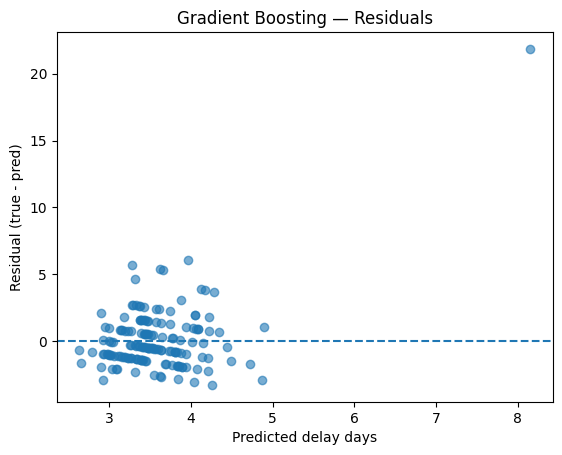

In [70]:
# residuals
resid = y_true_test - y_pred_test
plt.figure()
plt.scatter(y_pred_test, resid, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted delay days")
plt.ylabel("Residual (true - pred)")
plt.title("Gradient Boosting — Residuals")
plt.show()

In [71]:
# =========================
# PERMUTATION IMPORTANCE
# =========================
# build post-encoding feature names
# ohe = best_gbr.named_steps["prep"].named_transformers_.get("cat", None)
# ohe_cols = ohe.get_feature_names_out(cat_cols).tolist() if ohe is not None else []
# feat_names = num_cols + ohe_cols

# use log target for importance if you trained in log space
target_for_importance = y_test if USE_LOG_TARGET else y_test_raw

# perm = permutation_importance(best_gbr, X_test, target_for_importance, n_repeats=10,
#                               random_state=RANDOM_STATE, n_jobs=-1)
# imp = pd.Series(perm.importances_mean, index=feat_names).sort_values(ascending=False)
# print("\nTop 20 permutation importances:")
# print(imp.head(20))

# plt.figure(figsize=(8, 10))
# imp.head(25).iloc[::-1].plot(kind="barh")
# plt.title("Permutation Importance — Gradient Boosting")
# plt.tight_layout()
# plt.show()


Derived classification (threshold > 5 days):
[[138   0]
 [ 22   1]]
              precision    recall  f1-score   support

           0      0.863     1.000     0.926       138
           1      1.000     0.043     0.083        23

    accuracy                          0.863       161
   macro avg      0.931     0.522     0.505       161
weighted avg      0.882     0.863     0.806       161



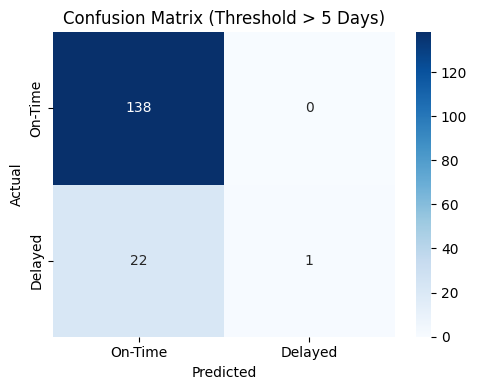

In [72]:
# =========================
# OPTIONAL: derive classification (>5 days)
# =========================
pred_is_delayed = (y_pred_test > DELAY_THRESHOLD).astype(int)
actual_is_delayed = (y_true_test > DELAY_THRESHOLD).astype(int)

print("\nDerived classification (threshold > 5 days):")
print(confusion_matrix(actual_is_delayed, pred_is_delayed))
print(classification_report(actual_is_delayed, pred_is_delayed, digits=3))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# --- Confusion Matrix Plot ---
cm = confusion_matrix(actual_is_delayed, pred_is_delayed)
labels = ['On-Time', 'Delayed']

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (Threshold > 5 Days)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Inferencing

In [74]:
import pandas as pd
import numpy as np

# Single new observation
new_data = pd.DataFrame([{
    "shipping_duration_days": 21,
    "lead_time_days": 60,
    "is_early_delivery": 0,
    "scac": "SMLU",
    "tariff_amount": 18847.5,
    "ocean_freight": 0.0,
    "delivery_terms": "CY",
    "po_shipment_terms": "DDP",
    "tariff_type": "Price With Tariff",
    "total_bcy": 167650.0,
    "quantity_in": 35000.0,
    "item_sku": "855",
    "item_brand": "GREAT VALUE",
    "item_manufacturer": "VANNAMEI",
    "item_product_category": "Goods",
    "item_size": "26/30",
    "vendor_name": "IPSP, INC.",
    "vendor_avg_delay_days": 5.8,
    "vendor_shipments": 5,
    "vendor_on_time_rate": 0.0,
    "vendor_p50_delay_days": 5,
    "vendor_p90_delay_days": 11,
    "shipped_date_weekday": 4,
    "shipped_date_month": 9,
    "shipped_date_day": 26,
    'distance_nm': 2100,
}])

# Keep columns in the same order as training
new_data = new_data[X.columns]


In [75]:
# Use trained pipeline (best_gbr from your GridSearchCV)
predicted_delay_log = best_gbr.predict(new_data)

# If you trained with log1p transform
predicted_delay_days = np.expm1(predicted_delay_log)

print(f"Predicted Delay Days: {predicted_delay_days[0]:.2f}")


Predicted Delay Days: 4.83


In [76]:
is_predicted_delayed = int(predicted_delay_days[0] > 5)
print("Predicted Class:", "DELAYED" if is_predicted_delayed else "ON-TIME")

Predicted Class: ON-TIME


Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-747463-tdr58kac for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-747463-47wr4_w6 for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-747463-bpddp5fy for automatic cleanup

## Explaning the result of Gradient Boosting

In [ ]:
# import shap

# # Create SHAP explainer
# explainer = shap.Explainer(best_gbr.named_steps['model'], 
#                            feature_names=best_gbr.named_steps['prep'].get_feature_names_out())

# # Compute SHAP values on your test data
# X_test_transformed = best_gbr.named_steps['prep'].transform(X_test)
# shap_values = explainer(X_test_transformed)

# # Global summary plot
# shap.summary_plot(shap_values, features=X_test_transformed, feature_names=best_gbr.named_steps['prep'].get_feature_names_out())


In [ ]:
# # 1️⃣ Transform the new data
# new_data_transformed = best_gbr.named_steps['prep'].transform(new_data)

# # 2️⃣ Get SHAP values
# shap_values_single = explainer(new_data_transformed)

# # 3️⃣ Visualize explanation for that one prediction
# shap.plots.waterfall(shap_values_single[0])


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# feature_names = best_gbr.named_steps['prep'].get_feature_names_out()
# importances = best_gbr.named_steps['model'].feature_importances_

# # Sort and plot
# indices = np.argsort(importances)[-20:]
# plt.figure(figsize=(8, 10))
# plt.barh(range(len(indices)), importances[indices], align='center')
# plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
# plt.title("Feature Importance — Gradient Boosting")
# plt.show()

## Explaning using LLM

In [ ]:
# from openai import OpenAI
# from dotenv import load_dotenv
# import os
# load_dotenv()

# client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
# system_prompt = """You are an expert data scientist specializing in machine learning model explanations. 
# Your task is to help explain the predictions of a Gradient Boosting regression model trained to predict shipment delay days.
# When given feature values for a shipment, provide a clear, concise explanation of features contributes to the predicted delay days.
# Focus on the most impactful features and their influence on the prediction.
# Try to keep the explanation based on the data provided.
# Try to find the root cause behind the delay.
# Avoid using technical jargon; explain in simple terms.
# Try to explain the predictions in 2 lines at maximum.

# Here is the idea behind the features provided:
# - shipping_duration_days: Expected duration of the shipment in days.
# - lead_time_days: Number of days between order placement and shipment.
# - is_early_delivery: Indicator if the delivery was early (1) or not (0).
# - coo: Country of origin of the shipment.
# - scac: Standard Carrier Alpha Code representing the shipping carrier.
# - tariff_amount: The tariff cost associated with the shipment.
# - ocean_freight: Cost of ocean freight for the shipment.
# - delivery_terms: Terms of delivery (e.g., CY, DDP).
# - po_shipment_terms: Purchase order shipment terms.
# - tariff_type: Type of tariff applied to the shipment.
# - total_bcy: Total cost in base currency.
# - quantity_in: Quantity of items in the shipment.
# - item_sku: Stock Keeping Unit identifier for the item.
# - item_brand: Brand of the item being shipped.
# - item_manufacturer: Manufacturer of the item.
# - item_product_category: Category of the product being shipped.
# - item_size: Size specification of the item.
# - vendor_name: Name of the vendor supplying the item.
# - vendor_avg_delay_days: Average delay days for shipments from this vendor.
# - vendor_shipments: Total number of shipments made by this vendor.
# - vendor_on_time_rate: Percentage of on-time deliveries by this vendor.
# - vendor_p50_delay_days: 50th percentile delay days for this vendor.
# - vendor_p90_delay_days: 90th percentile delay days for this vendor.
# - shipped_date_weekday: Day of the week the shipment was sent (0=Monday, 6=Sunday).
# - shipped_date_month: Month the shipment was sent (1-12).
# - shipped_date_day: Day of the month the shipment was sent (1-31).
# """

# user_query = f"""Given the following feature values for a shipment:
# {new_data.to_dict(orient='records')[0]}
# The model predicted a delay of {predicted_delay_days[0]:.2f} days.
# Please explain how the key features influenced this prediction.
# Shap values for the features are:
# {shap_values_single.values[0]}
# """


In [ ]:
# response = client.chat.completions.create(
#     model="gpt-4",
#     messages=[
#         {"role": "system", "content": system_prompt},
#         {"role": "user", "content": user_query}
#     ],
#     max_tokens=500,
#     temperature=0.7
# )

In [ ]:
# print(response.choices[0].message.content)

In [ ]:
# import pandas as pd

# # Define the data
# data = [
#     [7, 21, 60, 0, "ECUADOR", "SMLU", 18847.5, 0.0, "CY", "DDP", "Price With Tariff",
#      167650.0, 35000.0, "855", "GREAT VALUE", "VANNAMEI", "Goods", "26/30", "IPSP, INC.",
#      5.8, 5, 0.0, 5, 11, 4, 9, 26],
    
#     [4, 53, 108, 0, "VIETNAM", "MAEU", 27615.34, 3520.0, "Door Delivered", "DDP", "Price With Tariff",
#      160729.92, 29892.0, "1994", "MARKET SIDE", "AHI TUNA", "Goods", "3.5-5 OZ", "Anova",
#      3.33, 12, 0.0, 4, 4, 5, 8, 23],
    
#     [4, 53, 108, 0, "VIETNAM", "MAEU", 27615.34, 3520.0, "Door Delivered", "DDP", "Price With Tariff",
#      160729.92, 4452.0, "1994", "MARKET SIDE", "AHI TUNA", "Goods", "3.5-5 OZ", "Anova",
#      3.33, 12, 0.0, 4, 4, 5, 8, 23],
    
#     [4, 70, 89, 0, "INDIA", "MAEU", 54947.0, 6900.0, "CY", "DDP", "Price With Tariff",
#      181156.5, 34020.0, "857", "GREAT VALUE", "VANNAMEI", "Goods", "71/90", 
#      "Aquatica Frozen Foods Global Pvt Ltd", 4.38, 96, 0.0, 4, 6, 1, 8, 5],
    
#     [5, 60, 276, 0, "INDONESIA", "EGLV", 21660.57, 4218.0, "CY", "DDP", "Price With Tariff",
#      145353.6, 35280.0, "865", "GREAT VALUE", "VANNAMEI", "Goods", "21/25", 
#      "PT KHOM FOODS", 3.35, 20, 0.0, 3, 5, 3, 8, 14]
# ]

# # Define the column names
# columns = [
#     "delay_days", "shipping_duration_days", "lead_time_days", "is_early_delivery", 
#     "coo", "scac", "tariff_amount", "ocean_freight", "delivery_terms", "po_shipment_terms",
#     "tariff_type", "total_bcy", "quantity_in", "item_sku", "item_brand", 
#     "item_manufacturer", "item_product_category", "item_size", "vendor_name", 
#     "vendor_avg_delay_days", "vendor_shipments", "vendor_on_time_rate", 
#     "vendor_p50_delay_days", "vendor_p90_delay_days", "shipped_date_weekday", 
#     "shipped_date_month", "shipped_date_day"
# ]

# # Create the DataFrame
# df_new = pd.DataFrame(data, columns=columns)

# # Display
# print(df_new)


In [ ]:
# # Drop target if you're predicting (we already have delay_days here, but we can ignore it)
# X_new = df_new.drop(columns=["delay_days"])

# # Predict delay days
# pred_log = best_gbr.predict(X_new)
# pred_days = np.expm1(pred_log)
# df_new["predicted_delay_days"] = pred_days.round(2)

# # Derive classification (delayed vs not delayed)
# df_new["predicted_is_delayed"] = (df_new["predicted_delay_days"] > 5).astype(int)

# print(df_new[["vendor_name", "coo", "predicted_delay_days", "predicted_is_delayed"]])


Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-747463-inda994r for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-747463-_ytn270w for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-747463-smgjsedk for automatic cleanup